# **Project No: 01 P531 Drug Prediction**

# Task 01: Exploratory Data Analysis

In [220]:
import spacy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [221]:
df = pd.read_excel("drugsCom_raw.xlsx")
df.head()

,Unnamed: 0,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37


In [222]:
df.drop(['Unnamed: 0','drugName','date','usefulCount'],axis = 1,inplace = True) # Dropping unwanted columns
df.head()

,condition,review,rating
0,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9
1,ADHD,"""My son is halfway through his fourth week of ...",8
2,Birth Control,"""I used to take another oral contraceptive, wh...",5
3,Birth Control,"""This is my first time using any form of birth...",8
4,Opiate Dependence,"""Suboxone has completely turned my life around...",9


## Filtering the Data based on the required 3 Conditions
## 1. Depression
## 2. High Blood Pressure
## 3. Diabetes, Type 2'

In [223]:
df=df[df['condition'].isin(['Depression','High Blood Pressure','Diabetes, Type 2'])] #  Filtering the Data based on the required 3 Conditions
df.head()

,condition,review,rating
11,Depression,"""I have taken anti-depressants for years, with...",10
31,Depression,"""1 week on Zoloft for anxiety and mood swings....",8
44,Depression,"""my gp started me on Venlafaxine yesterday to ...",4
50,"Diabetes, Type 2","""Hey Guys, It&#039;s been 4 months since my l...",10
67,Depression,"""This medicine saved my life. I was at my wits...",10


## Removing the Duplicate and the Null rows if Present

In [224]:
df.isnull().sum() # is used to check for missing or null values in a pandas DataFrame

,0
condition,0
review,0
rating,0


In [225]:
df.duplicated().sum() # is used to check how many duplicate rows are present in a pandas DataFrame (df).

np.int64(4140)

In [226]:
df.drop_duplicates(inplace = True) # is used to remove duplicate rows from a pandas DataFrame (df).

In [227]:
df.duplicated().sum() # is used to check how many duplicate rows are present in a pandas DataFrame (df).

np.int64(0)

In [228]:
df.condition.unique() # is used to get the unique values from the condition column in a pandas DataFrame (df)

array(['Depression', 'Diabetes, Type 2', 'High Blood Pressure'],
      dtype=object)

In [229]:
df.condition.value_counts() # is used to count how many times each unique value appears in the condition column of a pandas DataFrame (df).

,count
condition,
Depression,6291
High Blood Pressure,1842
"Diabetes, Type 2",1671


In [230]:
df.rating.value_counts() # is used to count how many times each unique value appears in the rating column of a pandas DataFrame (df).

,count
rating,
10,2619
9,1723
1,1280
8,1254
7,717
5,538
6,477
2,456
3,419


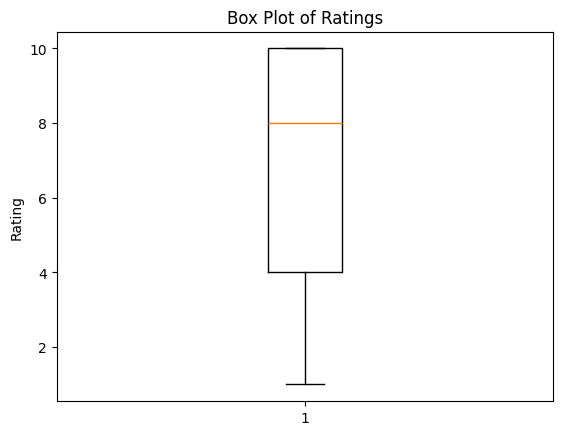

In [231]:
plt.boxplot(df["rating"])
plt.title("Box Plot of Ratings")
plt.ylabel("Rating")
plt.show()

In [232]:
import seaborn as sns # Seaborn is a Python data visualization library built on top of Matplotlib

# Bar Chart to visualise number of reviews per condition

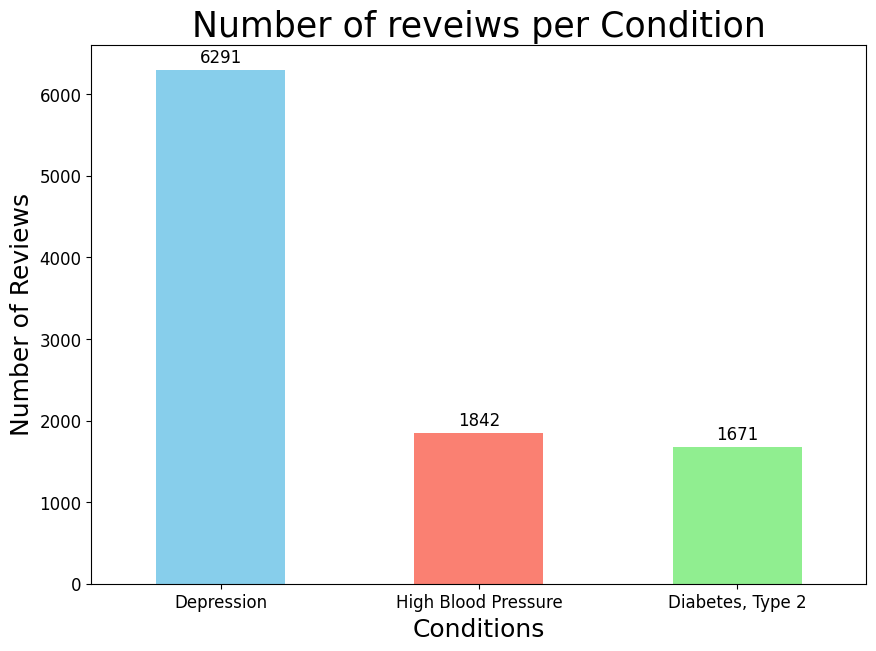

In [233]:
#sns.countplot(data=df,x='condition',order=df['condition'].value_counts().index)
plt.figure(figsize=(10,7)) # used to set the size of the figure (plot)

colors = ['skyblue', 'salmon', 'lightgreen']
ax=df['condition'].value_counts().plot(kind='bar', color=colors) # used to create a bar plot of the value counts of the condition column in the pandas DataFrame (df).

plt.title('Number of reveiws per Condition', size = 25, loc='center') # used to set the title of the plot

plt.xlabel('Conditions', size = 18) # used to customize the x-axis labels of a plot in Matplotlib
plt.xticks(rotation=0, size=12)

plt.ylabel('Number of Reviews', size = 18) # used to customize the x-axis labels of a plot in Matplotlib
plt.yticks(size=12)

ax.bar_label(ax.containers[0], padding=3, size=12) # is used to add labels to the bars of a bar plot in Matplotlib.
plt.show()

# Bar Chart to visualise number of reviews per ratings

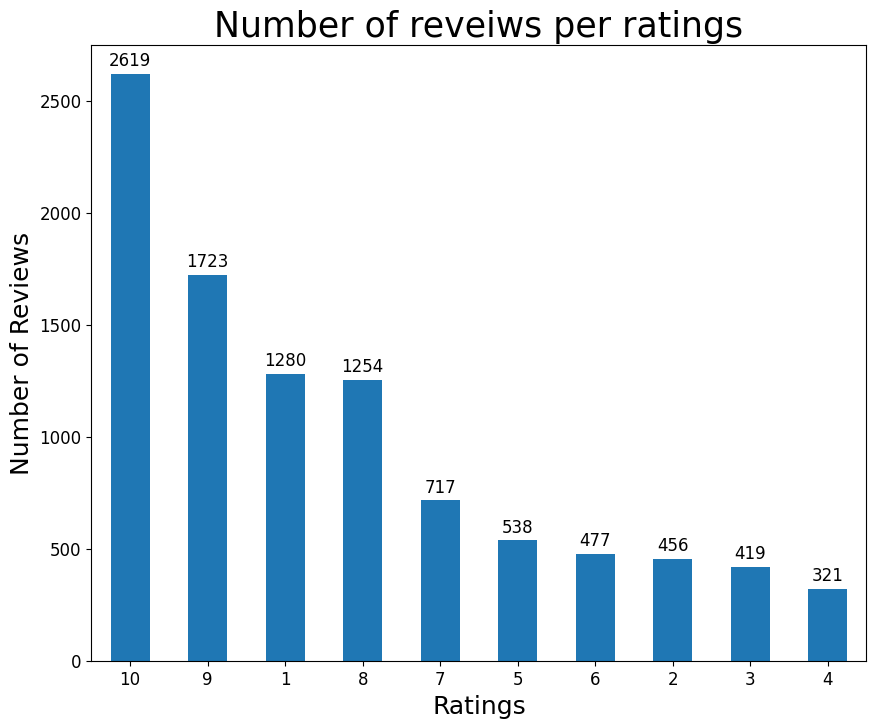

In [234]:
plt.figure(figsize=(10,8)) # used to set the size of the figure (plot)


ax=df['rating'].value_counts().plot(kind='bar') # used to create a bar plot of the value counts of the ratings column in the pandas DataFrame (df).

plt.title('Number of reveiws per ratings', size = 25, loc='center') # used to set the title of the plot

plt.xlabel('Ratings', size = 18) # used to customize the x-axis labels of a plot in Matplotlib
plt.xticks(rotation=0, size=12)

plt.ylabel('Number of Reviews', size = 18) # used to customize the y-axis labels of a plot in Matplotlib
plt.yticks(size=12)

ax.bar_label(ax.containers[0], padding=3, size=12) # is used to add labels to the bars of a bar plot in Matplotlib.
plt.show()

# Bar Chart to visualise average number of ratings per condition

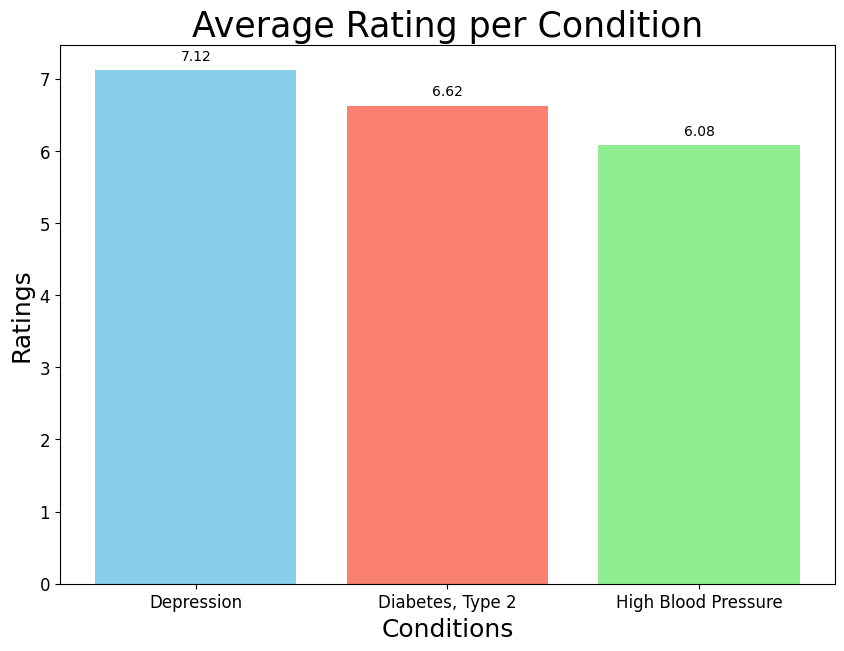

In [235]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7)) # used to set the size of the figure (plot)
colors = ['skyblue', 'salmon', 'lightgreen']

condition_ratings = df.groupby('condition')['rating'].mean().reset_index()  # Group data by condition and calculate average rating

ax=plt.bar(condition_ratings['condition'], condition_ratings['rating'], color=colors)   # Create the bar plot using the grouped data and average ratings

plt.title('Average Rating per Condition', size=25, loc='center') # used to set the title of the plot

plt.xlabel('Conditions', size=18) # used to customize the x-axis labels of a plot in Matplotlib
plt.xticks(rotation=0, size=12)

plt.ylabel('Ratings', size=18) # used to customize the y-axis labels of a plot in Matplotlib
plt.yticks(size=12)

for bar in ax:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, round(yval, 2), ha='center', va='bottom', size=10)

plt.show()

In [236]:
nlp = spacy.load("en_core_web_sm") # is used to load a pre-trained English language model in spaCy,

# Cleaning the reviews column using spacy

In [237]:
def spacy_preprocess(text):  #This defines a function named spacy_preprocess that takes one argument: text (expected to be a string).
    if pd.isnull(text):  #This checks if the input text is null (missing/NaN), If it is null, the function returns an empty string ("") to avoid errors later in the code.
        return ""

    doc = nlp(text.lower())  # Converts the text to lowercase and process with spaCy

    tokens = [] #Initializes an empty list to store the cleaned, processed tokens.
    for token in doc:

        if not token.is_stop and not token.is_punct and not token.like_num and not token.is_space and not token.is_bracket and not token.pos_ in ['SYM']:   # Removing Stopwords, Punctuations, Numbers, White spaces, Brackets, Symbols
            tokens.append(token.lemma_)  # Use the lemmatized version Ex. running --->  run, better ---> good, was ---> be

    return " ".join(tokens)  #Joins all the filtered and lemmatized tokens into a single string, separated by spaces, and returns it.


In [238]:
df['cleaned_review'] = df['review'].apply(spacy_preprocess) # is applying a text preprocessing function to clean up each review in the DataFrame.

In [239]:
df.head()

,condition,review,rating,cleaned_review
11,Depression,"""I have taken anti-depressants for years, with...",10,take anti depressant year improvement moderate...
31,Depression,"""1 week on Zoloft for anxiety and mood swings....",8,week zoloft anxiety mood swing mg morning brea...
44,Depression,"""my gp started me on Venlafaxine yesterday to ...",4,gp start venlafaxine yesterday help depression...
50,"Diabetes, Type 2","""Hey Guys, It&#039;s been 4 months since my l...",10,hey guy it&#039;s month post want month go wor...
67,Depression,"""This medicine saved my life. I was at my wits...",10,medicine save life wit end anti depressant rea...


In [240]:
from wordcloud import WordCloud # A Python library that helps you visualize word frequency using word clouds.

In [241]:
all_text = " ".join(df['cleaned_review'].dropna()) # Combining all preprocessed text reviews into one single string for further analysis or visualization.
all_text

'take anti depressant year improvement moderate severe affect make cymbalta pain begin deplin notice major improvement overnight energy well disposition sinking low low major depression take month feel like normal person time good thing effect week zoloft anxiety mood swing mg morning breakfast nausea day subside week go jitter hrs take follow yawn feel well angry stress gp start venlafaxine yesterday help depression change hour take feel sick couldn t stomach food fluid think tell come effect well take night ill couldn t stand sick sweat shaking thought go pass sleep hope feel well morning take feel space dry mouth shake sick book gp sure feel like find wrong dose mg mg right dose hope well hey guy it&#039;s month post want month go work trulicity month metformin hit month period diarrhea gas sulphur belching finally subside long effect haven&#039;t lose weight think start trulicity take glimepiride effect weight gain think med fight lol metformin trulicity week diagnose stage chronic

In [242]:
len(all_text)

2346629

# Using the cleaned reviews column for the WordCloud Visualisation

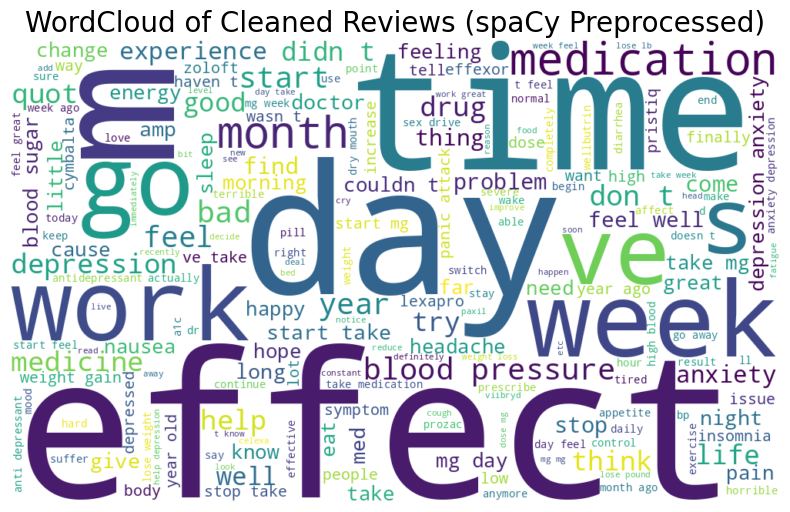

In [243]:
wordcloud = WordCloud(width=1000, height=600, background_color='white').generate(all_text) #Creates a WordCloud object with specific size and background color

plt.figure(figsize=(10, 6)) # used to set the size of the figure (plot)
plt.imshow(wordcloud, interpolation='bilinear') #displaying the generated word cloud image on a Matplotlib plot with smooth visual quality.
plt.axis('off') #To remove the axis lines, ticks, and labels from the plot.
plt.title("WordCloud of Cleaned Reviews (spaCy Preprocessed)", size=20)
plt.show()

In [244]:
conditions=df.condition.unique()
conditions

array(['Depression', 'Diabetes, Type 2', 'High Blood Pressure'],
      dtype=object)

# Word Cloud per Condition

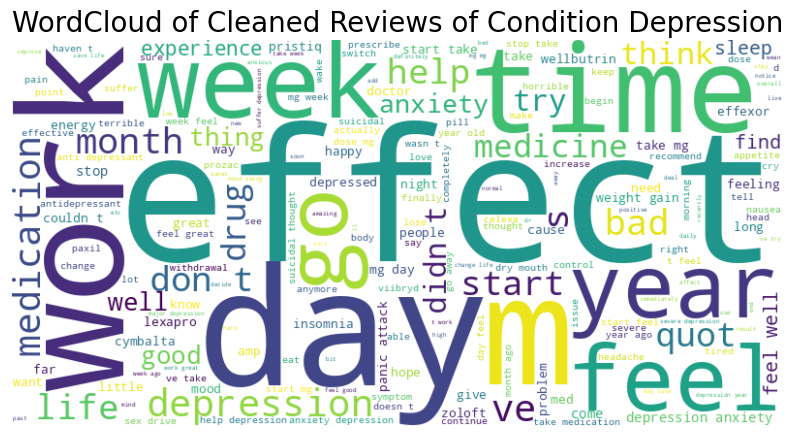

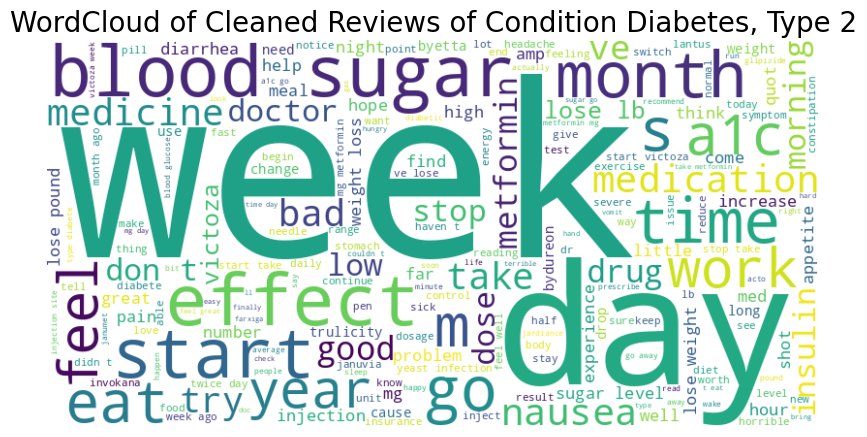

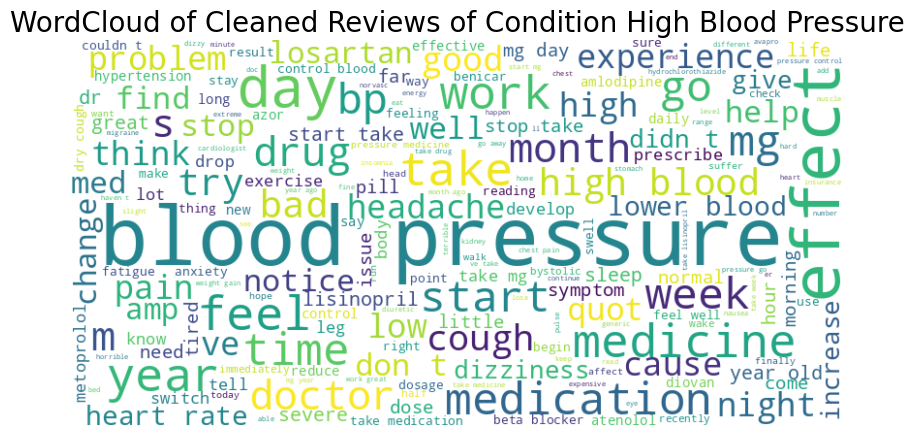

In [245]:
for cond in conditions:
  textc = " ".join(df[df['condition'] == cond]['cleaned_review'].dropna()) #Collect all the cleaned reviews for a specific condition (cond), and combine them into one large text string for analysis

  if not textc.strip():  #This checks if textc is empty or contains only whitespace, If yes, it skips this condition and goes to the next one using continue.
        continue

  wordcloud = WordCloud(width=800, height=400, background_color='white').generate(textc) #Generates the word cloud using the text (textc) specific to the current condition.

  plt.figure(figsize=(10, 6))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off')
  plt.title(f"WordCloud of Cleaned Reviews of Condition {cond}", size=20)

plt.show()

In [246]:
df.head()

,condition,review,rating,cleaned_review
11,Depression,"""I have taken anti-depressants for years, with...",10,take anti depressant year improvement moderate...
31,Depression,"""1 week on Zoloft for anxiety and mood swings....",8,week zoloft anxiety mood swing mg morning brea...
44,Depression,"""my gp started me on Venlafaxine yesterday to ...",4,gp start venlafaxine yesterday help depression...
50,"Diabetes, Type 2","""Hey Guys, It&#039;s been 4 months since my l...",10,hey guy it&#039;s month post want month go wor...
67,Depression,"""This medicine saved my life. I was at my wits...",10,medicine save life wit end anti depressant rea...


In [247]:
df.drop(columns='review', inplace=True)

In [248]:
df.head()

,condition,rating,cleaned_review
11,Depression,10,take anti depressant year improvement moderate...
31,Depression,8,week zoloft anxiety mood swing mg morning brea...
44,Depression,4,gp start venlafaxine yesterday help depression...
50,"Diabetes, Type 2",10,hey guy it&#039;s month post want month go wor...
67,Depression,10,medicine save life wit end anti depressant rea...


Feature engineering:

In [249]:
from sklearn.preprocessing import LabelEncoder
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
import pickle

In [250]:
lb= LabelEncoder()

In [251]:
arr = lb.fit_transform(df['condition'])

In [252]:
df['condition']= arr

In [253]:
df.head()

,condition,rating,cleaned_review
11,0,10,take anti depressant year improvement moderate...
31,0,8,week zoloft anxiety mood swing mg morning brea...
44,0,4,gp start venlafaxine yesterday help depression...
50,1,10,hey guy it&#039;s month post want month go wor...
67,0,10,medicine save life wit end anti depressant rea...


In [254]:
def sentiment_count(text):
    sent = TextBlob(text)
    sent_count = sent.sentiment.polarity
    return sent_count

In [255]:
rev = []
for i in df['cleaned_review']:
    count = sentiment_count(i)
    rev.append(count)

df['cleaned_review'] = rev

In [256]:
df.head()

,condition,rating,cleaned_review
11,0,10,0.139286
31,0,8,-0.500000
44,0,4,-0.269312
50,1,10,0.250000
67,0,10,0.211667


Sepearting feature and target column:

In [257]:
feature = df.drop('condition',axis=1)
target = df['condition']

In [258]:
x_train,x_test,y_train,y_test = train_test_split(feature,target,test_size=0.2,random_state=42,shuffle=True)

In [259]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(7843, 2) (1961, 2) (7843,) (1961,)


**Model building:**

1.Logistic Regression:

In [260]:
lr = LogisticRegression()

In [261]:
lr.fit(x_train, y_train)

LogisticRegression()

In [262]:
y_pred = lr.predict(x_train)

In [263]:
y_pred1 = lr.predict(x_test)

In [264]:
## Score checking:
lr_train_score = round(accuracy_score(y_train,y_pred)*100, 2)
lr_test_score = round(accuracy_score(y_test,y_pred1)*100, 2)

In [265]:
print('Training score :',lr_train_score)
print('Test score :',lr_test_score)

Training score : 64.07
Test score : 64.56


2.Support vector classifier:

In [266]:
svc = SVC()

In [267]:
svc.fit(x_train, y_train)

SVC()

In [268]:
y_pred = svc.predict(x_train)

In [269]:
y_pred1 = svc.predict(x_test)

In [270]:
## Score checking:
svc_train_score = round(accuracy_score(y_train,y_pred)*100, 2)
svc_test_score = round(accuracy_score(y_test,y_pred1)*100, 2)

In [271]:
print('Training score :',svc_train_score)
print('Test score :',svc_test_score)

Training score : 64.07
Test score : 64.56


3.Decession tree classifier:

In [272]:
dtc = DecisionTreeClassifier()

In [273]:
dtc.fit(x_train,y_train)

DecisionTreeClassifier()

In [274]:
y_pred = dtc.predict(x_train)

In [275]:
y_pred1 = dtc.predict(x_test)

In [276]:
dtc_train_score = round(accuracy_score(y_train,y_pred)*100, 2)
dtc_test_score = round(accuracy_score(y_test,y_pred1)*100, 2)

In [277]:
print('Training score :',dtc_train_score)
print('Test score :',dtc_test_score)

Training score : 83.63
Test score : 54.36


4. KNN:

In [278]:
knn = KNeighborsClassifier(n_neighbors=5)

In [279]:
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [280]:
y_pred = knn.predict(x_train)

In [281]:
y_pred1 = knn.predict(x_test)

In [282]:
knn_train_score = round(accuracy_score(y_train,y_pred)*100, 2)
knn_test_score = round(accuracy_score(y_test,y_pred1)*100, 2)

In [283]:
print('Training score :',knn_train_score)
print('Test score :',knn_test_score)

Training score : 65.87
Test score : 60.38


5.Gradient boost classifier:

In [284]:
gbc = GradientBoostingClassifier(n_estimators=50,learning_rate=0.5,subsample=0.9)

In [285]:
gbc.fit(x_train, y_train)

GradientBoostingClassifier(learning_rate=0.5, n_estimators=50, subsample=0.9)

In [286]:
y_pred = gbc.predict(x_train)

In [287]:
y_pred1 = gbc.predict(x_test)

In [288]:
gbc_train_score = round(accuracy_score(y_train,y_pred)*100, 2)
gbc_test_score = round(accuracy_score(y_test,y_pred1)*100, 2)

In [289]:
print('Training score :',gbc_train_score)
print('Test score :',gbc_test_score)

Training score : 66.79
Test score : 63.18


6.XGB:

In [290]:
xgb = XGBClassifier(learning_rate=0.1,gamma=10,reg_lambda=1,n_estimator=50,min_child_weight=2)

In [291]:
xgb.fit(x_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:44:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "n_estimator" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=10, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimator=50, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [292]:
y_pred = xgb.predict(x_train)

In [293]:
y_pred1 = xgb.predict(x_test)

In [294]:
xgb_train_score = round(accuracy_score(y_train,y_pred)*100, 2)
xgb_test_score = round(accuracy_score(y_test,y_pred1)*100, 2)

In [295]:
print('Training score :',xgb_train_score)
print('Test score :',xgb_test_score)

Training score : 64.07
Test score : 64.56


7. Ada boost:

In [296]:
ab = AdaBoostClassifier(n_estimators=100)

In [297]:
ab.fit(x_train, y_train)

AdaBoostClassifier(n_estimators=100)

In [298]:
y_pred = ab.predict(x_train)

In [299]:
y_pred1 = ab.predict(x_test)

In [300]:
ab_train_score = round(accuracy_score(y_train,y_pred)*100, 2)
ab_test_score = round(accuracy_score(y_test,y_pred1)*100, 2)

In [301]:
print('Training score :',ab_train_score)
print('Test score :',ab_test_score)

Training score : 64.07
Test score : 64.56


8.Bagging classifier:

In [302]:
bgc = BaggingClassifier(estimator= DecisionTreeClassifier(),n_estimators=50)

In [303]:
bgc.fit(x_train,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50)

In [304]:
y_pred = bgc.predict(x_train)

In [305]:
y_pred1 = bgc.predict(x_test)

In [306]:
bgc_train_score = round(accuracy_score(y_train,y_pred)*100, 2)
bgc_test_score = round(accuracy_score(y_test,y_pred1)*100, 2)

In [307]:
print('Training score :',bgc_train_score)
print('Test score :',bgc_test_score)

Training score : 83.5
Test score : 54.56


9. Random forest classifier:

In [308]:
rfc = RandomForestClassifier(n_estimators=50, max_features='log2')

In [309]:
rfc.fit(x_train, y_train)

RandomForestClassifier(max_features='log2', n_estimators=50)

In [310]:
y_pred = rfc.predict(x_train)

In [311]:
y_pred1 = rfc.predict(x_test)

In [312]:
rfc_train_score = round(accuracy_score(y_train,y_pred)*100, 2)
rfc_test_score = round(accuracy_score(y_test,y_pred1)*100, 2)

In [313]:
print('Training score :',rfc_train_score)
print('Test score :',rfc_test_score)

Training score : 83.48
Test score : 53.19


In [314]:
dict = {
    'Model':['Logistic Regression','Support vector classifier','Decession tree classifier','KNN','Gradient boost classifier','XGB','Ada boost','Bagging classifier','Random forest classifier'],
    'Training score':[lr_train_score,svc_train_score,dtc_train_score,knn_train_score,gbc_train_score,xgb_train_score,ab_test_score,bgc_train_score,rfc_train_score],
    'Test score':[lr_test_score,svc_test_score,dtc_test_score,knn_test_score,gbc_test_score,xgb_test_score,ab_test_score,bgc_test_score,rfc_test_score]
}

In [315]:
df1= pd.DataFrame(dict)
df1

,Model,Training score,Test score
0,Logistic Regression,64.07,64.56
1,Support vector classifier,64.07,64.56
2,Decession tree classifier,83.63,54.36
3,KNN,65.87,60.38
4,Gradient boost classifier,66.79,63.18
5,XGB,64.07,64.56
6,Ada boost,64.56,64.56
7,Bagging classifier,83.50,54.56
8,Random forest classifier,83.48,53.19


Visualising the models for the selection of best model:

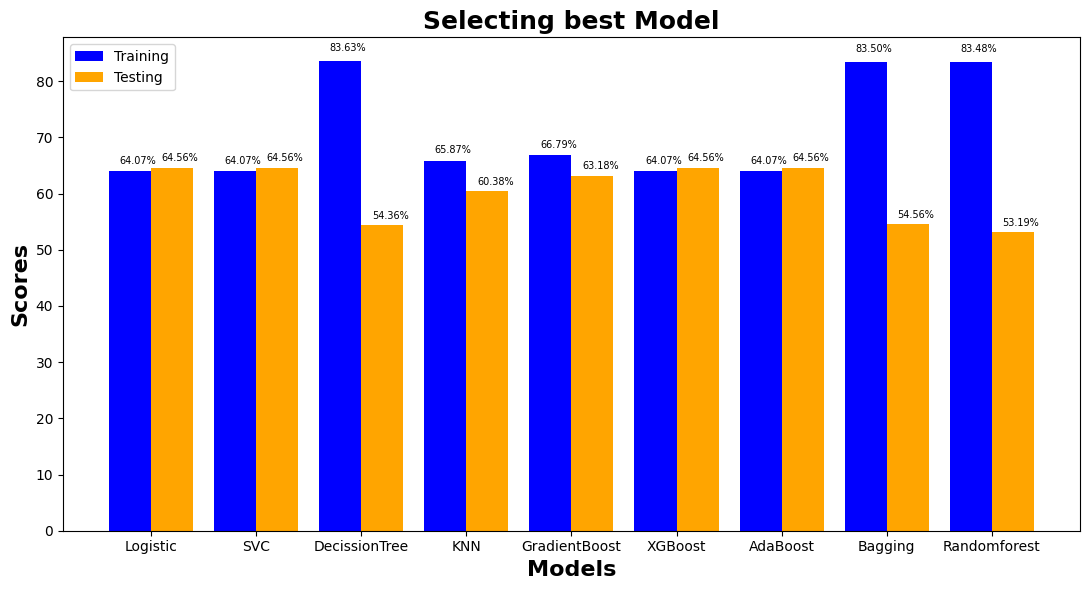

In [316]:
## Selecting model by visualizing scores:
models = ['Logistic', 'SVC', 'DecissionTree', 'KNN', 'GradientBoost', 'XGBoost', 'AdaBoost', 'Bagging', 'Randomforest']
trainig_scores = [lr_train_score, svc_train_score, dtc_train_score, knn_train_score, gbc_train_score, xgb_train_score, ab_train_score, bgc_train_score, rfc_train_score]
testing_scores = [lr_test_score,svc_test_score,dtc_test_score,knn_test_score,gbc_test_score,xgb_test_score,ab_test_score,bgc_test_score,rfc_test_score]

# Positions for the bars
x = np.arange(len(models))
bar_width = 0.4

# Create the plot
fig, ax = plt.subplots(figsize=(11, 6))

# Bars for the training group
bars1 = ax.bar(x - bar_width/2, trainig_scores, bar_width, label='Training', color='blue')
# Bars for the testing group
bars2 = ax.bar(x + bar_width/2, testing_scores, bar_width, label='Testing', color='orange')

# Add value labels on top of bars
for i, bar in enumerate(bars1):
    plt.text(bar.get_x() + bar.get_width()/2 - 0.1, bar.get_height()*1.02,
             s = '{:.2f}%'.format(trainig_scores[i]), fontsize = 7)

for i, bar in enumerate(bars2):
    plt.text(bar.get_x() + bar.get_width()/2 - 0.1, bar.get_height()*1.02,
             s = '{:.2f}%'.format(testing_scores[i]), fontsize = 7)

# Customize the plot
ax.set_xlabel('Models', fontsize = 16, fontweight = 'bold')
ax.set_ylabel('Scores', fontsize = 16, fontweight = 'bold')
ax.set_title('Selecting best Model', fontsize = 18, fontweight = 'bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [317]:
file ='model_gbc.pkl'
file1 = 'encoder_lb.pkl'

pickle.dump(gbc,open(file,'wb'))
pickle.dump(lb,open(file1,'wb'))